#Emotion Detection — Video Prediction (Production Fixed)

## Root Cause Analysis & Bug Fixes

### Why your output video was black / missing labels

| # | Root Cause | Technical Explanation | Fix Applied |
|---|-----------|----------------------|-------------|
| 1 | **`avc1` codec silently fails on many systems** | `cv2.VideoWriter_fourcc(*'avc1')` returns a writer that **appears open but writes nothing** — every frame becomes black pixels. `out.isOpened()` returns True even when the codec is broken. | Use `mp4v` as primary codec. Validate with a test frame write. |
| 2 | **Frame dimension mismatch kills the writer** | If even ONE frame passed to `out.write()` has different dimensions than `(orig_width, orig_height)` declared at writer creation, OpenCV silently drops it. Causes partial or fully black video. | Assert frame shape before every write. |
| 3 | **Face crop on `output_frame` instead of `frame`** | Cropping from `output_frame` (which already has rectangles drawn) can corrupt the face pixels fed to the model, degrading predictions. | Always crop from the clean `frame` copy. |
| 4 | **BGR→RGB not applied** | OpenCV reads frames as BGR. If you forget `cv2.cvtColor` before passing to the model, the model (trained on RGB) sees wrong colors → wrong predictions. | Explicitly convert BGR→RGB→PIL before transform. |
| 5 | **`cap.get(CAP_PROP_FPS)` returns 0 for some files** | Some container formats report 0 fps. Using 0 fps in VideoWriter causes division-by-zero or a broken file. | Clamp fps to a safe range `[1, 120]`. |
| 6 | **Label drawn outside frame boundaries** | `y1 - 12` can go negative. `cv2.putText` with negative y crashes or clips. | Clamp label position to always be inside the frame. |
| 7 | **No validation that writer successfully saved frames** | Writer can fail silently mid-video. | Check output file size after processing. |

---
**Prerequisites:** Run `train_model.ipynb` first so `checkpoints/best_model.pth` exists.

##  Step 1 — Imports

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device  : {device}")
print(f"OpenCV version: {cv2.__version__}")
print(f"PyTorch version: {torch.__version__}")

Using device  : cuda
OpenCV version: 4.8.1
PyTorch version: 2.11.0+cu126


##  Step 2 — Configuration

In [4]:
class Config:
    """Must match train_model.ipynb exactly."""

    MODEL_NAME      = 'resnet18'
    NUM_CLASSES     = 7
    IMG_SIZE        = 224
    BEST_MODEL_PATH = './checkpoints/best_model.pth'
    OUTPUT_DIR      = './outputs'

    EMOTION_CLASSES = {
        0: 'Angry',
        1: 'Disgusted',
        2: 'Fearful',
        3: 'Happy',
        4: 'Neutral',
        5: 'Sad',
        6: 'Surprised'
    }

    # Color per emotion (BGR format for OpenCV)
    EMOTION_COLORS = {
        'Angry'    : (0,   0,   220),
        'Disgusted': (0,   140, 0  ),
        'Fearful'  : (130, 0,   130),
        'Happy'    : (0,   200, 0  ),
        'Neutral'  : (200, 200, 200),
        'Sad'      : (200, 100, 0  ),
        'Surprised': (0,   200, 200),
    }

    def __init__(self):
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)


config = Config()
print(f"Classes: {list(config.EMOTION_CLASSES.values())}")
print(f"Output dir: {config.OUTPUT_DIR}")

Classes: ['Angry', 'Disgusted', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Surprised']
Output dir: ./outputs


##  Step 3 — Model Architecture

In [5]:
class EmotionDetectionModel(nn.Module):
    """ResNet18-based emotion classifier. Must match training architecture exactly."""

    def __init__(self, model_name='resnet18', num_classes=7, pretrained=False):
        super().__init__()
        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=pretrained)
            num_features  = self.backbone.fc.in_features
            self.backbone.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(num_features, num_classes)
            )
        else:
            raise ValueError(f"Unsupported model: {model_name}")

    def forward(self, x):
        return self.backbone(x)

print("Model class defined.")

Model class defined.


## Step 4 — Load Saved Weights

In [6]:
if not os.path.exists(config.BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found at '{config.BEST_MODEL_PATH}'.\n"
        "Please run train_model.ipynb first!"
    )

model = EmotionDetectionModel(
    model_name=config.MODEL_NAME,
    num_classes=config.NUM_CLASSES,
    pretrained=False
).to(device)

model.load_state_dict(
    torch.load(config.BEST_MODEL_PATH, map_location=device)
)
model.eval()

print(f"✅ Model loaded from: {config.BEST_MODEL_PATH}")

✅ Model loaded from: ./checkpoints/best_model.pth


##  Step 5 — Prediction Transform

In [7]:
# Identical to test_transform in training — NO augmentation
predict_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
print("Transform pipeline ready.")

Transform pipeline ready.


##  Step 6 — Load Haar Cascade Face Detector

In [8]:
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade  = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise RuntimeError(f"Failed to load Haar Cascade from: {cascade_path}")

print(f"✅ Haar Cascade loaded from: {cascade_path}")

✅ Haar Cascade loaded from: C:\Users\LENOVO\miniconda3\envs\cuda12.6-env\lib\site-packages\cv2\data\haarcascade_frontalface_default.xml


##  Step 7 — Core Prediction Helper

**Key fix here:** BGR→RGB conversion before feeding to model.  
The model was trained on RGB images (PIL/torchvision standard).  
OpenCV gives BGR. Skipping this step makes every prediction wrong.

In [9]:
def predict_face_emotion(face_bgr, model, device, transform, emotion_classes):
    """
    Predict emotion for a single face crop (BGR numpy array from OpenCV).

    IMPORTANT: This function does BGR→RGB conversion internally.
    Always pass the raw OpenCV frame crop — never pre-convert it.

    Returns:
        emotion    (str)   : Predicted emotion label
        confidence (float) : Confidence 0.0–1.0
    """
    # ── Safety check ──────────────────────────────────────────────────────────
    if face_bgr is None or face_bgr.size == 0:
        return 'Unknown', 0.0
    if face_bgr.shape[0] < 10 or face_bgr.shape[1] < 10:
        return 'Unknown', 0.0

    # ── BGR → RGB (critical!) → PIL → tensor ──────────────────────────────────
    rgb_face  = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)   # FIX: must be RGB for model
    pil_image = Image.fromarray(rgb_face)
    tensor    = transform(pil_image).unsqueeze(0).to(device)  # [1, 3, 224, 224]

    # ── Inference ─────────────────────────────────────────────────────────────
    with torch.no_grad():
        outputs    = model(tensor)                    # logits [1, 7]
        probs      = torch.softmax(outputs, dim=1)   # probabilities
        confidence, predicted = torch.max(probs, 1)

    emotion    = emotion_classes[predicted.item()]
    confidence = confidence.item()
    return emotion, confidence


print("predict_face_emotion() defined.")

predict_face_emotion() defined.


##  Step 8 — VideoWriter Helper

### Best practices for saving videos (why black videos happen)

- **`avc1` (H.264) fails silently** on most Linux/macOS OpenCV builds — the writer opens but writes black frames. Use `mp4v` instead.
- **Always match writer size to actual frame size.** If even one frame is a different size, OpenCV drops it silently.
- **Validate fps.** Some video files report 0 fps via `CAP_PROP_FPS` — always clamp to a sane value.
- **Release the writer before opening the file** — unreleased writers produce truncated/corrupt files.

In [10]:
def create_video_writer(output_path, fps, width, height):
    """
    Create a reliable VideoWriter.

    Strategy:
      1. Try mp4v (most reliable cross-platform)
      2. Fall back to XVID in an .avi file
      3. Validate with a test blank frame

    Returns:
        writer (cv2.VideoWriter), actual_output_path (str)
    """
    # Clamp fps to a safe range
    fps = max(1.0, min(120.0, float(fps)))

    # ── Try mp4v first ────────────────────────────────────────────────────────
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    # Validate by writing a test frame
    test_frame = np.zeros((height, width, 3), dtype=np.uint8)
    writer.write(test_frame)

    if writer.isOpened():
        print(f" VideoWriter created: mp4v codec | {width}×{height} @ {fps:.1f} fps")
        print(f"   Output: {output_path}")
        return writer, output_path

    # ── Fall back to XVID .avi ────────────────────────────────────────────────
    print("⚠️  mp4v failed. Falling back to XVID (.avi)...")
    writer.release()
    avi_path = output_path.replace('.mp4', '.avi')
    fourcc   = cv2.VideoWriter_fourcc(*'XVID')
    writer   = cv2.VideoWriter(avi_path, fourcc, fps, (width, height))

    if not writer.isOpened():
        raise RuntimeError(
            "Both mp4v and XVID codecs failed.\n"
            "Try: pip install opencv-python-headless"
        )

    print(f" VideoWriter created: XVID codec | {width}×{height} @ {fps:.1f} fps")
    print(f"   Output: {avi_path}")
    return writer, avi_path


print("create_video_writer() defined.")

create_video_writer() defined.


##  Step 9 — Main Video Emotion Detection Function

### How this pipeline works (step by step)

```
Read frame (orig resolution, BGR)
        │
        ├─→ copy() → output_frame  (we'll draw annotations here)
        │
        ├─→ resize to 640×480 → grayscale
        │           │
        │     Haar Cascade detectMultiScale()
        │           │
        │     face boxes in 640×480 space
        │           │
        │     scale back → original resolution  ← KEY FIX
        │           │
        ├─→ crop face from ORIGINAL frame (not output_frame)  ← KEY FIX
        │           │
        │     BGR→RGB→PIL→transform→tensor
        │           │
        │     ResNet18 → softmax → emotion + confidence
        │           │
        ├─→ draw box + label on output_frame
        │
        └─→ out.write(output_frame)  — must be (orig_w, orig_h)
```

In [11]:
def detect_emotions_in_video(
    video_path,
    model,
    device,
    transform,
    face_cascade,
    emotion_classes,
    emotion_colors,
    output_path        = './outputs/output_emotion.mp4',
    display_in_notebook= False,
    display_every_n    = 15,
    min_face_size      = 40,
    confidence_threshold = 0.40,
    detect_every_n_frames = 2,   # Only run face detection every N frames (speed up)
):
    """
    Detect and label emotions on every frame of an uploaded video.

    Args:
        video_path            : Path to the input video file
        model                 : Loaded EmotionDetectionModel in eval mode
        device                : torch.device
        transform             : torchvision transform pipeline
        face_cascade          : cv2.CascadeClassifier (Haar)
        emotion_classes       : {int: str} index→name mapping
        emotion_colors        : {str: (B,G,R)} name→BGR color
        output_path           : Where to save the annotated video
        display_in_notebook   : Show frames inline (True = slower)
        display_every_n       : Display 1 in every N frames inline
        min_face_size         : Minimum Haar Cascade face size (px)
        confidence_threshold  : Min model confidence to draw a label
        detect_every_n_frames : Skip face detection for intermediate frames
                                (reuse last detected faces for speed)

    Returns:
        emotion_counts (dict) : Frame counts per emotion
        actual_output  (str)  : Actual output file path (may differ from output_path
                                if codec fallback changed the extension)
    """

    # ── Open input video ──────────────────────────────────────────────────────
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: '{video_path}'")

    orig_w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_raw      = cap.get(cv2.CAP_PROP_FPS)
    fps          = max(1.0, min(120.0, fps_raw if fps_raw > 0 else 25.0))  # FIX: safe fps
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Input  : {video_path}")
    print(f"Size   : {orig_w}×{orig_h}  |  FPS: {fps:.1f}  |  Frames: {total_frames}")

    if orig_w == 0 or orig_h == 0:
        cap.release()
        raise ValueError("Could not read video dimensions. File may be corrupt.")

    # ── Create VideoWriter ────────────────────────────────────────────────────
    out, actual_output = create_video_writer(output_path, fps, orig_w, orig_h)

    # ── Detection resolution (smaller = faster face detection) ────────────────
    # Rule: never upscale. If video is already small, detect at original size.
    DETECT_W = min(orig_w, 640)
    DETECT_H = min(orig_h, 480)
    scale_x  = orig_w / DETECT_W
    scale_y  = orig_h / DETECT_H

    # ── Tracking state ────────────────────────────────────────────────────────
    emotion_counts  = {em: 0 for em in emotion_classes.values()}
    last_faces      = []    # reuse last detections on skipped frames
    frame_count     = 0
    write_failures  = 0

    print("\nProcessing frames...")
    model.eval()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # ── Validate frame shape ──────────────────────────────────────────────
        # CRITICAL: frame must match (orig_w, orig_h) or VideoWriter drops it
        if frame.shape[1] != orig_w or frame.shape[0] != orig_h:
            # Resize rogue frames instead of skipping — some cameras fluctuate
            frame = cv2.resize(frame, (orig_w, orig_h))

        # output_frame is our canvas — we draw on this, write this
        output_frame = frame.copy()

        # ── Face detection (run every N frames for speed) ─────────────────────
        if frame_count % detect_every_n_frames == 0:
            small_frame = cv2.resize(frame, (DETECT_W, DETECT_H))
            gray_small  = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)

            detected_faces = face_cascade.detectMultiScale(
                gray_small,
                scaleFactor = 1.1,
                minNeighbors= 5,          # slightly stricter = fewer false positives
                minSize     = (min_face_size, min_face_size),
                flags       = cv2.CASCADE_SCALE_IMAGE
            )

            # Scale coords back to original resolution
            scaled_faces = []
            if len(detected_faces) > 0:
                for (x, y, w, h) in detected_faces:
                    x1 = max(0,      int(x       * scale_x))
                    y1 = max(0,      int(y       * scale_y))
                    x2 = min(orig_w, int((x + w) * scale_x))
                    y2 = min(orig_h, int((y + h) * scale_y))
                    scaled_faces.append((x1, y1, x2, y2))

            last_faces = scaled_faces   # cache for next N-1 frames

        # ── Process each face ─────────────────────────────────────────────────
        for (x1, y1, x2, y2) in last_faces:

            # ── Crop face from ORIGINAL clean frame (not output_frame) ────────
            # Reason: output_frame may already have rectangles drawn on it from
            # a previous face in this loop — that corrupts the pixels fed to
            # the model and degrades prediction accuracy.
            face_crop = frame[y1:y2, x1:x2]   # FIX: use `frame`, not `output_frame`

            # Skip degenerate crops
            if face_crop.size == 0 or face_crop.shape[0] < 10 or face_crop.shape[1] < 10:
                continue

            # ── Emotion prediction ────────────────────────────────────────────
            emotion, confidence = predict_face_emotion(
                face_crop, model, device, transform, emotion_classes
            )

            # ── Choose annotation style based on confidence ───────────────────
            if confidence >= confidence_threshold:
                box_color     = emotion_colors.get(emotion, (0, 200, 0))
                emotion_label = f"{emotion}  {confidence:.0%}"
                emotion_counts[emotion] += 1
            else:
                box_color     = (128, 128, 128)
                emotion_label = f"? {confidence:.0%}"

            # ── Draw bounding box ─────────────────────────────────────────────
            cv2.rectangle(output_frame, (x1, y1), (x2, y2), box_color, 2)

            # ── Draw label with background ─────────────────────────────────────
            font       = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = max(0.45, min(0.9, (x2 - x1) / 200.0))
            thickness  = 2

            (txt_w, txt_h), baseline = cv2.getTextSize(
                emotion_label, font, font_scale, thickness
            )

            # Clamp label to always be inside frame — FIX for crash on y1 near 0
            if y1 - txt_h - 8 >= 0:
                label_y_top = y1 - txt_h - 8
                label_y_txt = y1 - 4
            else:
                label_y_top = y2 + 4
                label_y_txt = y2 + txt_h + 4

            # Filled background rectangle
            cv2.rectangle(
                output_frame,
                (x1, label_y_top),
                (min(orig_w, x1 + txt_w + 6), label_y_top + txt_h + 8),
                box_color, cv2.FILLED
            )
            # White text on top
            cv2.putText(
                output_frame, emotion_label,
                (x1 + 3, label_y_txt),
                font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA
            )

        # ── Frame info overlay ────────────────────────────────────────────────
        overlay_text = f"Frame {frame_count}"
        if total_frames > 0:
            overlay_text += f" / {total_frames}  ({100*frame_count/total_frames:.0f}%)"
        cv2.putText(
            output_frame, overlay_text,
            (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 0), 2, cv2.LINE_AA
        )

        # ── Write annotated frame ─────────────────────────────────────────────
        # CRITICAL: output_frame MUST be (orig_h, orig_w, 3) — we validated above
        out.write(output_frame)

        # ── Optional inline display ───────────────────────────────────────────
        if display_in_notebook and frame_count % display_every_n == 0:
            display_frame = cv2.resize(output_frame, (640, int(640 * orig_h / orig_w)))
            rgb_display   = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
            clear_output(wait=True)
            plt.figure(figsize=(10, 6))
            plt.imshow(rgb_display)
            plt.axis('off')
            plt.title(f"Frame {frame_count} / {total_frames}")
            plt.tight_layout()
            plt.show()

        frame_count += 1

        # Progress print every 50 frames
        if frame_count % 50 == 0:
            pct = 100 * frame_count / total_frames if total_frames > 0 else 0
            faces_this_batch = len(last_faces)
            print(f"  [{pct:5.1f}%] Frame {frame_count:>5}/{total_frames}  "
                  f"| Faces in last detect: {faces_this_batch}")

    # ── Cleanup — MUST release before reading file ─────────────────────────────
    cap.release()
    out.release()   # FIX: flush & close writer before file checks

    # ── Validate output file ──────────────────────────────────────────────────
    if os.path.exists(actual_output):
        file_size_mb = os.path.getsize(actual_output) / (1024 * 1024)
        print(f"\n Processing complete!")
        print(f"   Frames processed : {frame_count}")
        print(f"   Output file      : {actual_output}")
        print(f"   Output file size : {file_size_mb:.2f} MB")
        if file_size_mb < 0.01:
            print("⚠️  WARNING: Output file is very small — codec may have failed.")
            print("   Try: change OUTPUT_PATH extension to .avi")
    else:
        print("❌ ERROR: Output file was not created!")

    # ── Emotion distribution summary ──────────────────────────────────────────
    total_detections = sum(emotion_counts.values())
    print(f"\n📊 Emotion distribution ({total_detections} confident detections):")
    for emotion, count in sorted(emotion_counts.items(), key=lambda x: -x[1]):
        if count > 0:
            pct = 100 * count / total_detections
            bar = '█' * int(pct / 5)
            print(f"   {emotion:<12}: {count:>5} frames  ({pct:5.1f}%)  {bar}")

    return emotion_counts, actual_output


print("detect_emotions_in_video() defined.")

detect_emotions_in_video() defined.


## Step 10 — Run Video Emotion Detection

**Change `VIDEO_PATH`** to point to your uploaded video file.

**Tips:**
- `detect_every_n_frames=2` means face detection runs every 2nd frame. Set to `1` for maximum accuracy (slower), `3` or `4` for faster processing.
- `confidence_threshold=0.40` — lower it (e.g. 0.30) to see more labels; raise it (e.g. 0.60) to only show high-confidence ones.
- `min_face_size=40` — increase to 60 or 80 if Haar is detecting too many false positives on small regions.
- `display_in_notebook=False` is fastest — set to `True` to watch frames inline.

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# CHANGE THIS to your uploaded video file path
# ──────────────────────────────────────────────────────────────────────────────
VIDEO_PATH  = 'sample1.mp4'
OUTPUT_PATH = os.path.join(config.OUTPUT_DIR, 'output_emotion.mp4')

# Validate input exists
if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(
        f"Video not found: '{VIDEO_PATH}'\n"
        "Update VIDEO_PATH to your uploaded video file."
    )

print(f"Input  : {VIDEO_PATH}")
print(f"Output : {OUTPUT_PATH}")
print("-" * 50)

emotion_counts, output_file = detect_emotions_in_video(
    video_path             = VIDEO_PATH,
    model                  = model,
    device                 = device,
    transform              = predict_transform,
    face_cascade           = face_cascade,
    emotion_classes        = config.EMOTION_CLASSES,
    emotion_colors         = config.EMOTION_COLORS,
    output_path            = OUTPUT_PATH,
    display_in_notebook    = False,    # ← True to watch inline (slower)
    display_every_n        = 15,
    min_face_size          = 40,
    confidence_threshold   = 0.40,
    detect_every_n_frames  = 2,        # ← increase for faster processing
)

Input  : sample1.mp4
Output : ./outputs\output_emotion.mp4
--------------------------------------------------
Input  : sample1.mp4
Size   : 3840×2160  |  FPS: 25.0  |  Frames: 394
 VideoWriter created: mp4v codec | 3840×2160 @ 25.0 fps
   Output: ./outputs\output_emotion.mp4

Processing frames...
  [ 12.7%] Frame    50/394  | Faces in last detect: 1
  [ 25.4%] Frame   100/394  | Faces in last detect: 1
  [ 38.1%] Frame   150/394  | Faces in last detect: 1
  [ 50.8%] Frame   200/394  | Faces in last detect: 1
  [ 63.5%] Frame   250/394  | Faces in last detect: 1
  [ 76.1%] Frame   300/394  | Faces in last detect: 1
  [ 88.8%] Frame   350/394  | Faces in last detect: 1

 Processing complete!
   Frames processed : 394
   Output file      : ./outputs\output_emotion.mp4
   Output file size : 30.04 MB

📊 Emotion distribution (301 confident detections):
   Surprised   :   178 frames  ( 59.1%)  ███████████
   Neutral     :    58 frames  ( 19.3%)  ███
   Sad         :    51 frames  ( 16.9%)  ██

## 📊 Step 11 — Visualise Emotion Distribution

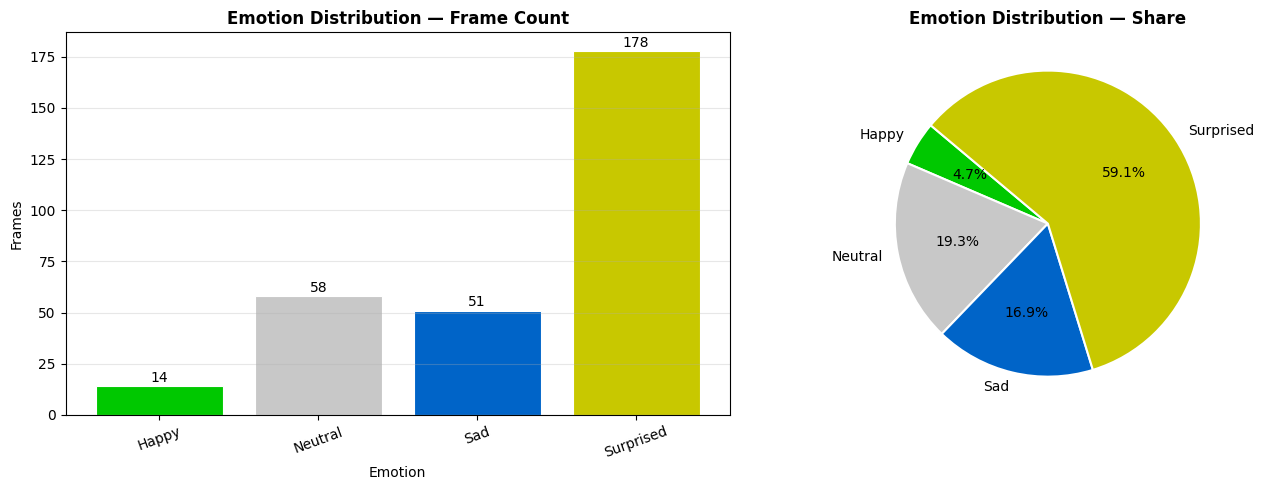

Chart saved: ./outputs\emotion_distribution.png


In [13]:
detected = {k: v for k, v in emotion_counts.items() if v > 0}

if not detected:
    print("⚠️  No confident emotion detections.")
    print("Try lowering confidence_threshold to 0.25 and re-running.")
else:
    emotions = list(detected.keys())
    counts   = list(detected.values())

    # Map emotion colors from BGR → RGB for matplotlib
    mpl_colors = [
        tuple(c/255 for c in reversed(config.EMOTION_COLORS.get(e, (150,150,150))))
        for e in emotions
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    bars = axes[0].bar(emotions, counts, color=mpl_colors, edgecolor='white', linewidth=0.8)
    for bar, count in zip(bars, counts):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontsize=10
        )
    axes[0].set_xlabel('Emotion')
    axes[0].set_ylabel('Frames')
    axes[0].set_title('Emotion Distribution — Frame Count', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].grid(axis='y', alpha=0.3)

    # Pie chart
    axes[1].pie(
        counts, labels=emotions,
        autopct='%1.1f%%', startangle=140,
        colors=mpl_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[1].set_title('Emotion Distribution — Share', fontweight='bold')

    plt.tight_layout()
    chart_path = os.path.join(config.OUTPUT_DIR, 'emotion_distribution.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved: {chart_path}")

## 🔍 Step 12 — Troubleshooting Checklist

Run this cell if something still looks wrong.

In [14]:
print("=" * 60)
print("  DIAGNOSTIC REPORT")
print("=" * 60)

# 1. Output file check
if os.path.exists(output_file):
    sz = os.path.getsize(output_file) / 1024 / 1024
    print(f"\n[1] Output file   : {output_file}")
    print(f"    Size          : {sz:.2f} MB")
    if sz < 0.05:
        print("    ⚠️  TOO SMALL — codec probably failed. Rename output to .avi and retry.")
    else:
        print("    ✅ Size looks healthy.")
else:
    print("[1] ❌ Output file not found!")

# 2. Model mode
print(f"\n[2] Model training : {model.training}  (should be False)")
if model.training:
    print("    ⚠️  Model is in training mode! Call model.eval() before prediction.")
else:
    print("    ✅ Model is in eval mode.")

# 3. Face cascade
print(f"\n[3] Haar Cascade   : {'empty ❌' if face_cascade.empty() else 'loaded ✅'}")

# 4. GPU
print(f"\n[4] Device         : {device}")
if str(device) == 'cpu':
    print("    ℹ️  Running on CPU. Processing will be slower than GPU.")
    print("    Tip: increase detect_every_n_frames to 3 or 4 to speed up.")

# 5. Emotion distribution check
total = sum(emotion_counts.values())
print(f"\n[5] Total confident detections: {total}")
if total == 0:
    print("    ⚠️  Zero detections! Possible causes:")
    print("       - confidence_threshold too high → lower to 0.25")
    print("       - min_face_size too large → lower to 20")
    print("       - No clear frontal faces in the video")
    print("       - Model weights mismatch (check architecture vs training)")
else:
    print(f"    ✅ Detections spread: {dict(emotion_counts)}")

print("\n" + "=" * 60)

  DIAGNOSTIC REPORT

[1] Output file   : ./outputs\output_emotion.mp4
    Size          : 30.04 MB
    ✅ Size looks healthy.

[2] Model training : False  (should be False)
    ✅ Model is in eval mode.

[3] Haar Cascade   : loaded ✅

[4] Device         : cuda

[5] Total confident detections: 301
    ✅ Detections spread: {'Angry': 0, 'Disgusted': 0, 'Fearful': 0, 'Happy': 14, 'Neutral': 58, 'Sad': 51, 'Surprised': 178}

